# **LAB 07**

## **Esercizio 7.1**

In questo esercizio sono state implementate le correzioni di coda (*tail correction*) per l'energia potenziale e la pressione in un sistema di particelle interagenti tramite potenziale di Lennard-Jones con cut-off.

Per simulare in modo efficiente il potenziale di Lennard-Jones non lo si calcola fino ad infinito, ma si introduce un cutoff $r_c$: per distanze superiori a questo $r_c$ i contributi vengono ignorati. Dunque, il sistema simulato non è esattamente quello fisico ma una sua approssimazione. Le correzioni di coda si occupano proprio di andare a stimare matematicamente la "parte mancante", ovvero da $r_c$ a infinito. Assumento un sistema omogeneo, è possibile integrare il potenziale da $r_c$ a $\infty$, ottenendo così le correzioni: 

$$ \frac{U_{tail}}{N} = \frac{8 \pi \rho}{3} \left ( \frac{1}{3r_c^9} - \frac{1}{r_c^3} \right ) $$

$$ \frac{P_{tail}}{3N} = 32 \pi \rho \left ( \frac{1}{9r_c^9} - \frac{1}{6r_c^3} \right )$$

Per introdurre queste correzioni di coda è stata modificata la funzione `initialize_properties()`.  

## **Esercizio 7.2**

#### INTRODUZIONE
L'obiettivo di questo esercizio è studiare le proprietà termodinamiche di un sistema di particelle interagenti tramite simulazioni Monte Carlo (MC) nell'ensemble canonico (NVT) e Molecular Dynamics (MD) nell'ensemble microcanonico (NVE): in particolare, si analizzano le fluttuazioni dell’energia potenziale per particella $\frac{U}{N}$ in condizioni di equilibrio termodinamico. Nel Monte Carlo (MC) si lavora nell'ensemble canonico, in cui il numero di particelle N, il volume V e la temperatura T sono fissati. Il sistema non evolve nel tempo fisico, ma viene esplorato lo spazio delle configurazioni tramite mosse stocastiche accettate secondo il criterio di Metropolis, che garantisce il campionamento della distribuzione di Boltzmann. Il “tempo” MC rappresenta quindi soltanto il numero di tentativi di aggiornamento e non ha significato dinamico. Nel Molecular Dynamics (MD), invece, il sistema evolve secondo le equazioni del moto di Newton nell'ensemble microcanonico, in cui N, V ed energia E sono costanti. L'evoluzione è deterministica e il tempo corrisponde al tempo fisico reale del sistema. Questo metodo permette di studiare la dinamica microscopica e i tempi di rilassamento del sistema.

Le simulazioni sono state eseguite nel regime liquido con i seguenti parametri: 
- densità ridotta $\rho^* = 0.8$
- temperatura ridotta $T^* = 1.1$
- raggio di cutoff $r_c^* = 2.5$



#### EQUILIBRAZIONE DEL SISTEMA
Prima della produzione dei dati vera e propria, è necessario portare il sistema in equilibrio termodinamico. 

Si consideri innanzitutto il caso di Molecular Dynamics. Partendo da una configurazione cristallina perfetta, si osserva che la temperatura inizialmente non è stabile: è quindi necessario determinare una temperatura iniziale opportuna in modo che, a seguito di una certa evoluzione, il sistema raggiunga una temperatura media stabile pari a $T^* = 1.1$. La temperatura da cui partire è risultata essere $\sim 1.98$. Dunque, prima della simulazione vera e propria, è stata svolta una simulazione di equilibrazione senza acquisizione di dati da 20 blocchi con 2000 step ciascuno, prendendo come configurazione iniziale `config.fcc`. A questo punto sono state salvate le configurazioni finali dell'equilbrazione, che verranno poi utilizzate come input per la simulazione successiva. 


Anche nel caso Monte Carlo è necessaria una fase di equilibrazione iniziale: bisogna imporre il parametro di passo $\Delta = 0.1$, in modo da ottenere un'accettanza del 50% (ovvero il rapporto tra il numero di mosse accettate e il numero totale di mosse proposte). Dal punto di vista fisico, l'accettanza misura quanto il sistema riesce ad esplorare lo spazio delle configurazioni e quanto si muove liberamente nello spazio delle fasi. Se il passo $\Delta$ è troppo piccolo, quasi tutte le mosse vengono accettate ma il sistema evolve lentamente; se è troppo grande, la maggior parte delle mosse viene rifiutata e il sistema rimane bloccato. Per ottenere una simulazione efficiente, si sceglie un valore di $\Delta$ tale da avere un’accettanza di circa il 50%, che rappresenta un compromesso ottimale tra esplorazione dello spazio delle configurazioni e accettazione delle mosse. Analogamente all'equilibrazione nel caso MD, è stata svolta una simulazione da 20 blocchi con 2000 step ciascuno senza acquisizione di dati e con salvataggio delle configurazioni finali. 


#### AUTOCORRELAZIONE 
A seguito dell'equilibrazione, entrambe le simulazioni vengono riavviate utilizzando le configurazioni finali equilibrate e si eseguono $5 \cdot 10^5$ step di simulazione, registrando i valori istantanei di $\frac{U}{N}$. 

A questo punto si calcola la funzione di autocorrelazione dell'energia potenziale per particella. Infatti, da entrambe le simulazioni si ottiene una sequenza temporale di energie potenziali: la funzione di autocorrelazione determina se, data una certa energia ad un certo tempo, dopo $i$ passi questa energia è ancora simile oppure il sistema ha dimenticato lo stato iniziale; in altre parole, l'autocorrelazione determina il tempo di memoria del sistema. Nel Monte Carlo il "tempo" non è un tempo fisico ma è il numero di mosse della catena di Markov: dunque, l'autocorrelazione in questo caso dice dopo quanti step MC i dati diventano statisticamente indipendenti. Invece, in Molecular Dynamics il tempo è reale e quindi l'autocorrelazione misura i tempi di rilassamento fisico. Nel caso in cui si trova che l'autocorrelazione decresce rapidamente significa che il sistema è "ben mescolato"; se invece decresce lentamente significa che il sistema ha una forte memoria, che implica meno efficienza statistica. 

Questa funzione di autocorrelazione è definita come: 

$$\rho(t) =
\frac{\left\langle (x_i - \langle x \rangle)(x_{i+t} - \langle x \rangle) \right\rangle}
{\left\langle (x_i - \langle x \rangle)^2 \right\rangle}$$

Di seguito è riportato il grafico che raffigura l'autocorrelazione dei dati provenienti dalle due simulazioni in funzione del \emph{lag}, ovvero il numero di passi temporali (MC) o di intervalli di tempo (MD) che separano due misure della stessa osservabile. Si nota che entrambe le curve mostrano un decadimenro entro circa 200 step. Inoltre, confrontando i due metodi, si osserva che in MC l'autocorrelazione decade più rapidamente rispetto che in MD, anche se oltre i 200/300 step il comportamento delle due autocorrelazioni diventa molto simile, prossimo allo zero. 

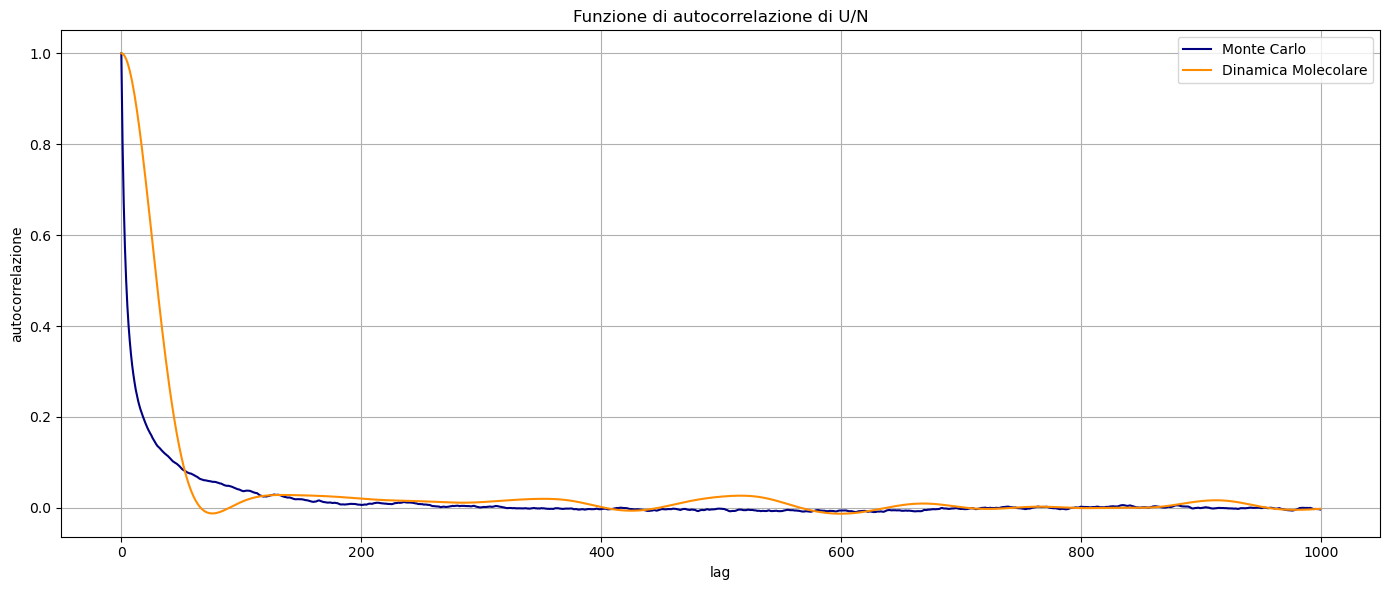

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# CARICAMENTO DATI
U_MC = np.loadtxt("esercizio7.1_7.2/NSL_SIMULATOR/OUTPUT/instant_penergy_MC.dat") # qui sono stampati i valori istantanei dell'energia
U_MD = np.loadtxt("esercizio7.1_7.2/NSL_SIMULATOR/OUTPUT/instant_penergy_MD.dat")


max_lag = 1000

# Definizione funzione autocorrelazione
def autocorrelation(U, max_lag):
    U = np.array(U)
    mean = np.mean(U)
    var = np.mean((U - mean)**2)
    N = len(U)
    result = []
    for i in range(max_lag):
        U1 = U[:N - i]
        U2 = U[i:]
        # covarianza a lag i
        cov = np.mean((U1 - mean) * (U2 - mean))
        result.append(cov / var)
    return np.array(result)


# Calcolo delle autocorrelazioni
autocorrelation_MC = autocorrelation(U_MC, max_lag)
autocorrelation_MD = autocorrelation(U_MD, max_lag)
t_calcolati = np.arange(max_lag)


# PLOT
plt.figure(figsize=(14, 6))

plt.plot(t_calcolati, autocorrelation_MC, label="Monte Carlo", color="navy")
plt.plot(t_calcolati, autocorrelation_MD, label="Dinamica Molecolare", color="darkorange")

plt.title("Funzione di autocorrelazione di U/N")
plt.xlabel("lag")
plt.ylabel("autocorrelazione")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#### INCERTEZZA STATISTICA
Per stimare correttamente l'incertezza statistica dell'energia potenziale $\braket{\frac{U}{N}}$, è necessario tenere conto delle correlazioni temporali presenti nei dati generati dalle simulazioni Monte Carlo e Molecular Dynamics. Infatti, i valori successivi dell’energia non sono indipendenti: questo porta a una sottostima dell’errore se si utilizza direttamente la deviazione standard sui dati grezzi.

Per risolvere questo problema si utilizza il metodo della media a blocchi. La procedura consiste nel suddividere la serie temporale in blocchi di lunghezza L, calcolare la media all’interno di ciascun blocco e poi stimare l’errore a partire dalla dispersione tra le medie dei blocchi. Per verificare quando i blocchi possono essere considerati indipendenti, si studia l’andamento dell’errore stimato in funzione della dimensione del blocco L. 

Dal grafico qui riportato, si conclude che per piccoli valori di $L$ i dati all'interno dei blocchi sono fortemente correlati e quindi l'errore risulta sottostimato. Invece, all'aumentare di $L$ le correlazioni interne ai blocchi diminuiscono e l'errore cresce fino a stabilizzarsi. Dunque, per valori sufficientemente grandi di $L$, l'errore raggiunge un plateau che rappresenta la stima corretta dell'incertezza statistica. Confontando i dati MD e MC, si nota che nel caso MD le correlazioni temporali sono generalmente più lunghe e quindi il plateau viene raggiunto per valori di $L$ più grandi; viceversa, nel caso MC campioni tendono a decorrelarsi più rapidamente e il plateau viene raggiunto prima.

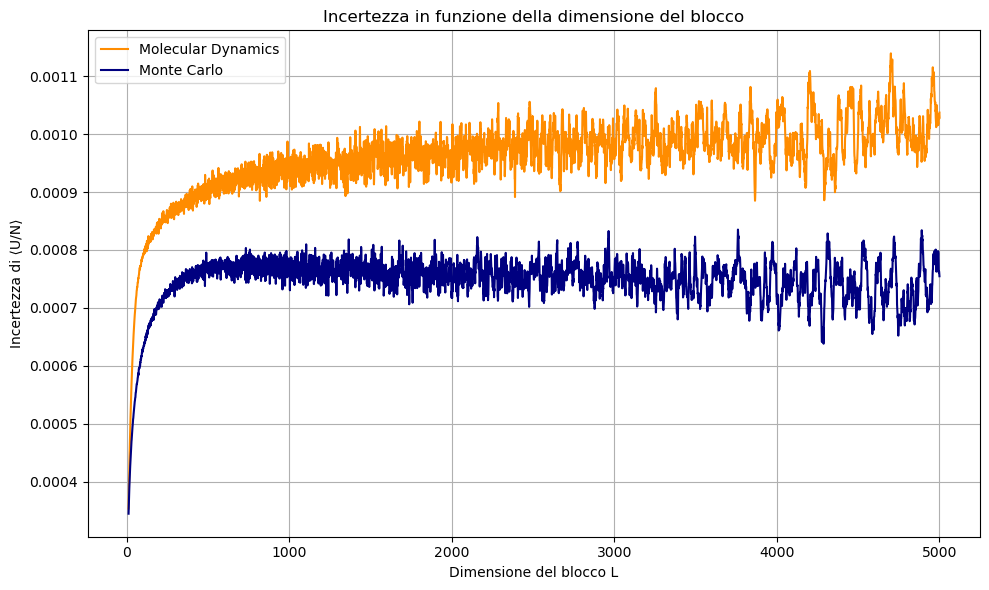

In [12]:
# DEFINIZIONE FUNZIONE MEDIA A BLOCCHI
def media_blocchi (data, L): # L = dimensione blocco
    M=len(data)    # numero di dati
    N=M//L         # numero di blocchi
    
    if N<2:
        return None, None
        
    blocks = data[:N*L].reshape(N, L)     # taglio di eventuali dati in eccesso e trasformazione del vettore in una matrice (ogni riga è un blocco)
    block_means = np.mean(blocks, axis=1) # media di ogni blocco
    avg = np.mean(block_means)            # calcola media dei blocchi
    std_err = np.std(block_means, ddof=1) / np.sqrt(N) 
    return avg, std_err

# CARICAMENTO DATI
data_MC = np.loadtxt("esercizio7.1_7.2/NSL_SIMULATOR/OUTPUT/instant_penergy_MC.dat")
data_MD = np.loadtxt("esercizio7.1_7.2/NSL_SIMULATOR/OUTPUT/instant_penergy_MD.dat")
M = len(data_MD) 

 
block_sizes = np.arange(10,5001,1) 
errors_md = []
errors_mc = []
valid_L = []

for L in block_sizes: 
    _, err_md = media_blocchi(data_MD, L) # ignora la media (interessa solo l'errore)
    _, err_mc = media_blocchi(data_MC, L)
    if err_md is not None and err_mc is not None:
        errors_md.append(err_md)
        errors_mc.append(err_mc)
        valid_L.append(L)

#plot
plt.figure(figsize=(10, 6))
plt.plot(valid_L, errors_md, label="Molecular Dynamics", color='darkorange')
plt.plot(valid_L, errors_mc, label="Monte Carlo", color='navy')
plt.xlabel("Dimensione del blocco L")
plt.ylabel("Incertezza di ⟨U/N⟩")

plt.title("Incertezza in funzione della dimensione del blocco")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## **Esercizio 7.3**

Questo esercizio consiste nell'implementazione della funzione di distribuzione radiale $g(r)$. Questa funzione misura la probabilità di trovare una particella a distanza $r$ da un'altra rispetto ad un gas ideale. Se $g(r)=1$, allora il sistema si comporta come un gas ideale, ovvero a quella distanza le particelle non si influenzano; invece, se $g(r)>1$: questa distanza è favorita, mentre se $g(r)<1$: questa distanza è sfavorita. 

Per un fluido omogeneo, la GOFR è definita come:
$$ g(r) = \frac{1}{\rho N \Delta V(r)} \braket{\sum_{i \neq j = 1}^N \delta(r - |\vec{r}_i - \vec{r}_j|)} $$
dove $\Delta V(r) = \frac{4\pi}{3} [(r+dr)^3 - r^3]$ è il volume del guscio sferico di spessore $dr$.


Al fine di implementare $g(r)$, inizialmente è stata modificata la funzione `System :: measure()` all’interno del blocco `_measure_gofr` per costruire l’istogramma delle distanze tra particelle. Per ogni coppia di particelle $(i,j)$ viene calcolata la distanza $dr$ utilizzando le condizioni al contorno periodiche. Se la distanza rientra nell’intervallo considerato per $g(r)$, viene individuato il bin corrispondente e il suo valore viene incrementato di 2 unità. Questo fattore 2 tiene conto del fatto che ogni coppia contribuisce due volte, come $(i,j)$ e $(j,i)$. Successivamente è stata modificata la funzione `System :: averages`, in modo da includere la media a blocchi della funzione di distribuzione radiale $g(r)$. In questa fase, i contributi istantanei accumulati durante la simulazione vengono mediati all’interno di ciascun blocco statistico, ottenendo così una stima più stabile e meno rumorosa dell’osservabile. Per ogni bin dell’istogramma delle distanze, il valore medio nel blocco viene successivamente normalizzato tenendo conto del numero di particelle, della densità del sistema e del volume del guscio sferico corrispondente. Questa procedura permette di trasformare i conteggi discreti in una funzione continua $g(r)$, direttamente confrontabile con il comportamento atteso di un gas ideale.

## **Esercizio 7.4**

#### INTRODUZIONE 
Una volta implementate le nuove funzioni dell'esercizio 7.3, queste possono essere sfruttate per confrontare i risultati che si ottengono dalla simulazione di uno stesso sistema con due tipologie di simulazione differenti, ovvero Monte Carlo nell’ensemble canonico (NVT) e la Dinamica Molecolare nell’ensemble microcanonico (NVE). Sebbene i due metodi siano concettualmente differenti (il primo basato sul campionamento stocastico delle configurazioni, il secondo sull’evoluzione deterministica delle equazioni del moto) entrambi devono descrivere lo stesso stato di equilibrio e quindi fornire risultati compatibili per le grandezze macroscopiche.

Si sceglie di andare a studiare un sistema di particelle interagenti tramite potenziale di Lennard-Jones, utilizzato come modello per descrivere l’Argon. In particolare, si vuole analizzare le seguenti grandezze: energia potenziale per particella $U/N$, pressione $P$ e funzione di distribuzione radiale $g(r)$. 

Le simulazioni sono state eseguite nel regime liquido con i seguenti parametri: 
- densità ridotta $\rho^* = 0.8$
- temperatura ridotta $T^* = 1.1$
- raggio di cutoff $r_c^* = 2.5$


#### PRESSIONE 
In generale, la pressione microscopica nei sistemi di particelle si ottiene dalla formula del viriale:

$$ P = \rho T + \frac{1}{3V} \braket{\sum_{i<j} \vec{r}_{ij} \cdot \vec{F}_{ij}}$$

dove si vede che sono presenti due termini (cinetico e di interazione). 

Nel caso della Dinamica Molecolare, le particelle hanno velocità reali e quindi esiste un'energia cinetica definita. Dunque, è possibile scrivere $T= \frac{2}{3} \braket{K}$. Tuttavia, in Monte Carlo non c'è dinamica e non esistono velocità fisiche: non è quindi possibile utilizzare $K$ per il calcolo della temperatura, la quale è imposta dall'ensemble. In altre parole, la temperatura è un paramentro della distribuzione. Al fine di implementare correttamente la funzione responsabile del calcolo della pressione, è stata modificata la funzione `System :: measure()` nel seguente modo: 

```cpp
if (_measure_pressure) {
    if (_sim_type == 0) {
        _measurement[_index_pressure] = _rho * (2.0/3.0) * kenergy_temp + (_ptail * _npart + 48.0 * virial / 3.0) / _volume;
    }
    if (_sim_type == 1) {
        _measurement[_index_pressure] = _rho * _temp + (_ptail * _npart + 48.0 * virial / 3.0) / _volume;
    }
}

#### EQUILIBRAZIONE E PRODUZIONE DEI DATI
Come già descritto nell'esercizio 7.2, il sistema è stato inizialmente sottoposto ad una fase di equilibrazione necessaria per permettere al sistema di raggiungere uno stato stazionario indipendente dalla configurazione iniziale. Una volta verificata la stabilizzazione delle principali osservabili, si è proceduto con la fase di produzione dei dati. Per entrambi i metodi, è stata svolta una simulazione da 30 blocchi con 2000 step ciascuno; nel caso MD il delta utilizzato è di 0.001, mentre in MC è 0.1.

#### ANALISI DATI
Innanzitutto, si considerino i grafici della pressione e dell'energia interna per particella. I valori medi mostrati nei grafici in funzione dei blocchi risultano simili per entrambe le grandezze considerate. Tuttavia, si osservano leggere discrepanze tra i risultati ottenuti mediante Monte Carlo e Molecular Dynamics, che non risultano pienamente compatibili entro le incertezze statistiche. Tali differenze possono essere attribuite principalmente alla presenza di effetti statistici residui, dovuti alla lunghezza finita delle simulazioni e all’autocorrelazione tra configurazioni successive. Inoltre, i due metodi campionano lo stesso insieme statistico in modo rigorosamente equivalente solo nel limite termodinamico ($N \to \infty$). Nel caso in esame, il numero finito di particelle ($N=108$) può quindi contribuire a piccole differenze tra i risultati. Nel complesso, le osservabili mostrano comunque un buon accordo qualitativo, indicando che entrambi i metodi forniscono una descrizione coerente dello stato di equilibrio del sistema.

Se invece si osservano i due grafici di $g(r)$, si nota che questa funzione mostra l’andamento caratteristico di un fluido nella fase liquida. In particolare, si osserva che $g(r)$ tende a zero per valori piccoli di $r$, a causa della forte repulsione del potenziale di Lennard-Jones a corta distanza, che impedisce alle particelle di sovrapporsi. Aumentando la distanza compare un primo picco pronunciato, che identifica la distanza più probabile tra una particella e i suoi primi vicini: in entrambe le simulazioni questo picco si trova a $r=1.06$ ed è indice della presenza di un ordine locale ben definito, tipico dei liquidi. 
Successivamente si osservano ulteriori oscillazioni, via via meno marcate, che riflettono la presenza di gusci di coordinazione successivi, ma con un ordine che si perde progressivamente all’aumentare della distanza. Per valori grandi di $r$, la funzione tende a 1, come atteso per un sistema omogeneo, indicando che le correlazioni tra particelle diventano trascurabili e che la distribuzione spaziale tende a quella di un gas ideale su larga scala. Il confronto tra i risultati ottenuti mediante simulazioni Monte Carlo e Molecular Dynamics evidenzia un buon accordo tra le due curve.

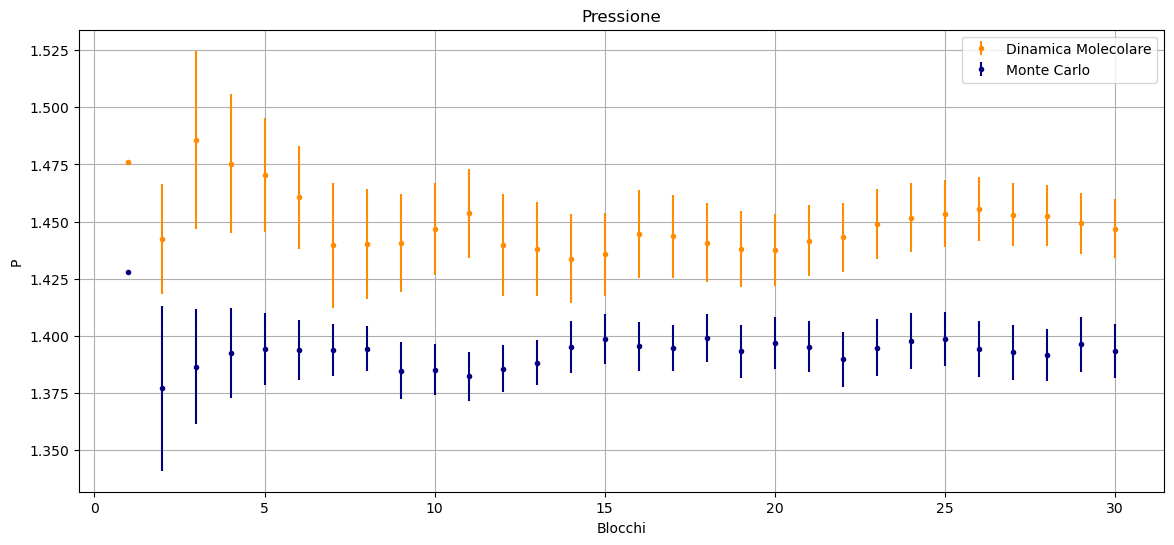

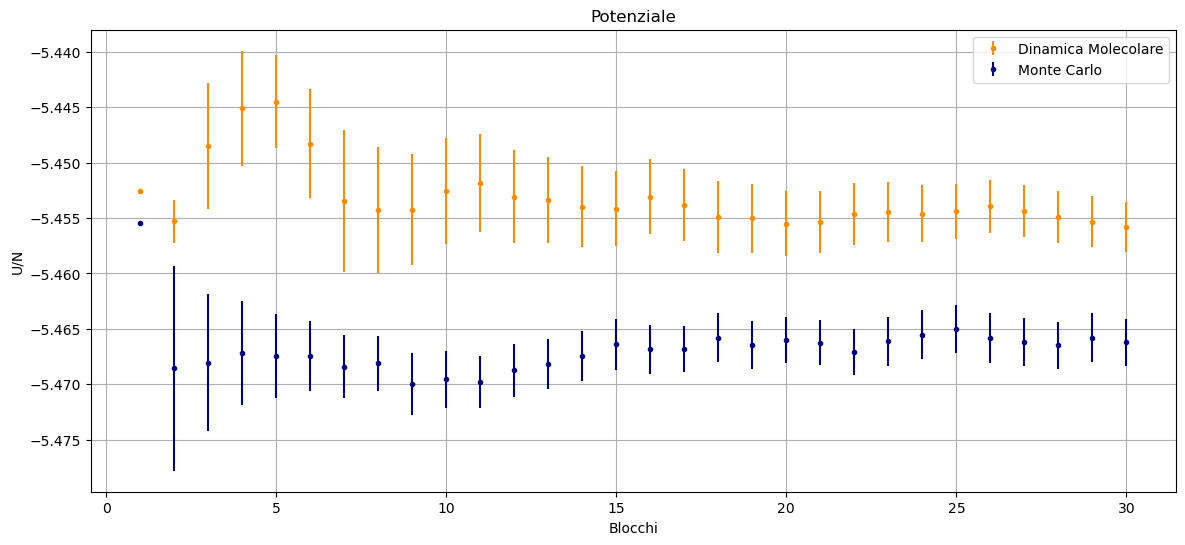

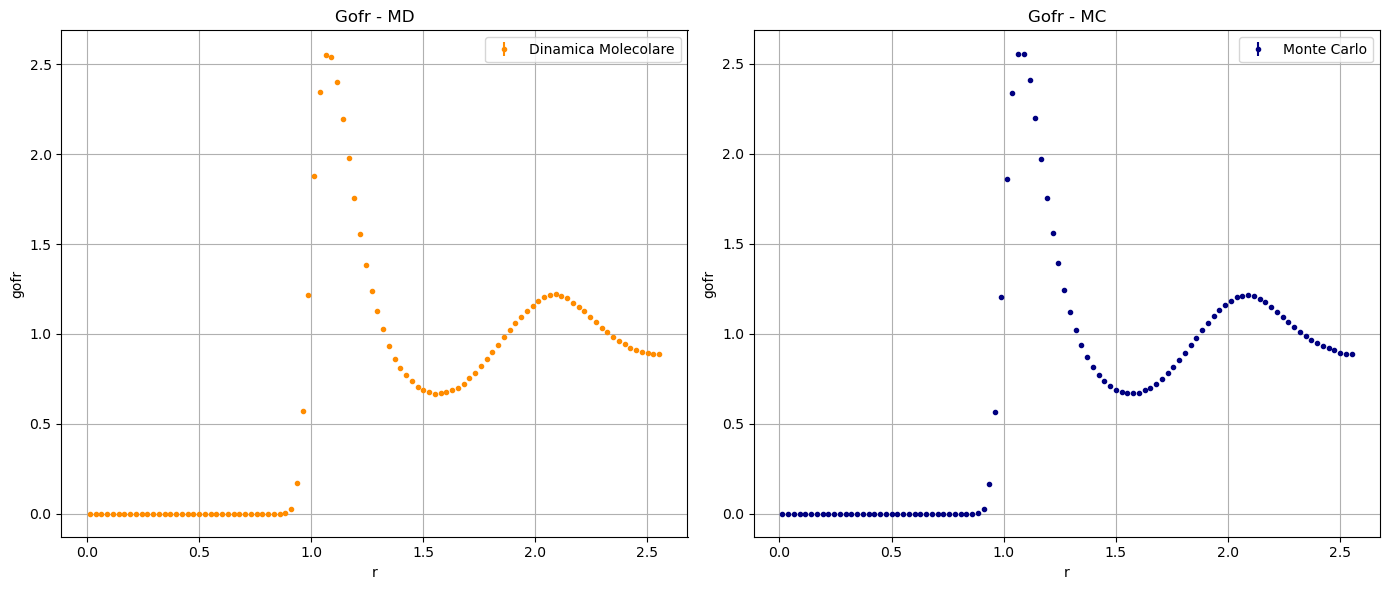

MD:
Massimo g(r) = 2.55 a r = 1.06

MC:
Massimo g(r) = 2.56 a r = 1.06


In [15]:
import numpy as np
import matplotlib.pyplot as plt


# CARICAMENTO DATI
pressione_MD = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MD/pressure.dat")
potenziale_MD = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MD/potential_energy.dat")
gofr_MD = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MD/gofr.dat")

pressione_MC = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MC/pressure.dat")
potenziale_MC = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MC/potential_energy.dat")
gofr_MC = np.loadtxt("esercizio7.3_7.4/NSL_SIMULATOR/OUTPUT_MC/gofr.dat")

pressione_blk_MD = pressione_MD[:,0]
pressione_ave_MD = pressione_MD[:,2]
pressione_err_MD = pressione_MD[:,3]
potenziale_blk_MD = potenziale_MD[:,0]
potenziale_ave_MD = potenziale_MD[:,2]
potenziale_err_MD = potenziale_MD[:,3]
gofr_bin_MD = gofr_MD[:,0]
gofr_ave_MD = gofr_MD[:,2]
gofr_err_MD = gofr_MD[:,3]

pressione_blk_MC = pressione_MC[:,0]
pressione_ave_MC = pressione_MC[:,2]
pressione_err_MC = pressione_MC[:,3]
potenziale_blk_MC = potenziale_MC[:,0]
potenziale_ave_MC = potenziale_MC[:,2]
potenziale_err_MC = potenziale_MC[:,3]
gofr_bin_MC = gofr_MC[:,0]
gofr_ave_MC = gofr_MC[:,2]
gofr_err_MC = gofr_MC[:,3]

# PLOT PRESSIONE
plt.figure(figsize=(14, 6))
plt.errorbar(pressione_blk_MD, pressione_ave_MD, yerr=pressione_err_MD, fmt='o', label="Dinamica Molecolare", color="darkorange", markersize=3)
plt.errorbar(pressione_blk_MC, pressione_ave_MC, yerr=pressione_err_MC, fmt='o', label="Monte Carlo", color="navy", markersize=3)
plt.title("Pressione")
plt.xlabel("Blocchi")
plt.ylabel("P")
plt.legend()
plt.grid(True)
plt.show()

# PLOT ENERGIA INTERNA
plt.figure(figsize=(14, 6))
plt.errorbar(potenziale_blk_MD, potenziale_ave_MD, yerr=potenziale_err_MD, fmt='o', label="Dinamica Molecolare", color="darkorange", markersize=3)
plt.errorbar(potenziale_blk_MC, potenziale_ave_MC, yerr=potenziale_err_MC, fmt='o', label="Monte Carlo", color="navy", markersize=3)
plt.title("Potenziale")
plt.xlabel("Blocchi")
plt.ylabel("U/N")
plt.legend()
plt.grid(True)
plt.show()

# PLOT GOFR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 riga, 2 colonne

axes[0].errorbar(gofr_bin_MD, gofr_ave_MD, yerr=gofr_err_MD,
                 fmt='o', label="Dinamica Molecolare",
                 color="darkorange", markersize=3)
axes[0].set_title("Gofr - MD")
axes[0].set_xlabel("r")
axes[0].set_ylabel("gofr")
axes[0].legend()
axes[0].grid(True)

axes[1].errorbar(gofr_bin_MC, gofr_ave_MC, yerr=gofr_err_MC,
                 fmt='o', label="Monte Carlo",
                 color="navy", markersize=3)
axes[1].set_title("Gofr - MC")
axes[1].set_xlabel("r")
axes[1].set_ylabel("gofr")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# DETERMINAZIONE DEI MASSIMI
idx_max_MD = np.argmax(gofr_ave_MD)
r_max_MD = gofr_bin_MD[idx_max_MD]
gmax_MD = gofr_ave_MD[idx_max_MD]
print("MD:")
print(f"Massimo g(r) = {gmax_MD:.2f} a r = {r_max_MD:.2f}")

idx_max_MC = np.argmax(gofr_ave_MC)
r_max_MC = gofr_bin_MC[idx_max_MC]
gmax_MC = gofr_ave_MC[idx_max_MC]
print("\nMC:")
print(f"Massimo g(r) = {gmax_MC:.2f} a r = {r_max_MC:.2f}")